<a href="https://colab.research.google.com/github/tessamcnuggets/Shivani-and-Tessa-Electron-Spin-Model/blob/main/SwaminathanS_DunaganT_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 6: Phase Transitions in the 2D Ising Model

(Adapted from Blundell and Blundell section 28.8)

Background

The 2D Ising Model is the simplest possible model that displays phase transitions! The Ising Model is a lattice model, as discussed in lab. Each site in the lattice is occupied with a magnetic particle (for example, an electron) that has a magnetic moment (for example, a spin) that can take one of two values: “up” (+1) or “down” (-1). The magnetic particles interact with each other via nearest-neighbor interactions (with periodic boundary conditions) such that if two spins are alike, they lower the total energy by J, and if two spins are different, they raise the total energy by J. The value J is known as the coupling constant.

To showcase a phase transition, we will need to implement the Metropolis Monte Carlo algorithm. This algorithm is known to converge on the equilibrium distribution if a large enough number of simulation steps are run. This algorithm goes as follows:
Pick a random spin in the lattice; attempt to flip it (up → down or down → up)
Compute the new energy of the lattice
If the new energy goes down, accept the flip
If the new energy goes up, generate a random number between 0 and 1.
If that number is less than exp(–(Enew - Eold) / T) accept the step
Otherwise, reject the step
Repeat

The “magic step” where we compare a random number to the function that depends on the change in energy and the temperature ensures that we only accept steps with probability exp(–(Enew - Eold) / T), which ensures that we will equilibrate to the Boltzmann distribution – which is the probability distribution of being at an energy E when we are at temperature T.

Simulation
Implement the Metropolis Monte Carlo algorithm described above for J = 1 and T = 1 using a 500 x 500 lattice. Run at least 106 simulation steps. Before conducting any analysis, discard the first 105 simulation steps because these steps are not at equilibrium.
The starting point of your simulation should be a random collection of spin-up and spin-down particles
If T = 0.000001 (i.e., you are close to absolute zero), you should reject all uphill steps and all of the particles should align to the same spin
If T = 100000 (i.e., you are at a very high temperature), you should accept every single step and the final arrangement of particles should be completely random
From theory, the critical temperature is known to be approximately Tc = 2.269. Run at least 20 simulations for a range of temperatures that includes the critical temperature somewhere in the middle.
Compute the average energy for each simulation. Make a plot of average energy versus temperature, and show that there is an inflection point at the critical temperature.
Compute the heat capacity C of the lattice for each simulation using the following formula:

C = E2/ T2

Where E2 is the variance in the energy over the course of the simulation and T is the temperature. Plot C versus T, and show that C is discontinuous at the critical temperature.

Generate movies of three of your simulations: at T = 1, T = 2.27, and T = 5. To do this, look up the matplotlib animation documentation. You’ll basically need to make a plot of your simulation every 10,000 steps (or so – may need to play with this number), and then stitch all of those plots together using the animation module to generate a movie.

Analysis
Explain why the low-temperature and high-temperature limits of your simulation behave as expected based on the Metropolis criterion. What does this mean about the most probable state of the spins at very low and very high temperatures?
A phase transition can be defined as occurring as a temperature where the heat capacity is discontinuous. How do your data show the existence of the ferromagnetic phase transition in the Ising model? Why does long-range ordering happen in this model based on the interactions that are modelled?
What happens to the critical temperature as the coupling energy parameter J increases? Conceptually, why does this happen?

Extensions
In your presentation, make connections to at least two other phenomena that can be modeled in a similar way.
One additional analysis or simulation extension decided by you


In [ ]:
'''
Authors: Shivani Swaminathan and Tessa Dunagan
Consulted: Professor Smaranda Sandu, Professor Michael Mavros
Date: 5/4/2026
Purpose: Ising model for CS112 final project
'''

'\nAuthors: Shivani Swaminathan and Tessa Dunagan\nConsulted: Professor Smaranda Sandu, Professor Michael Mavros\nDate: 5/4/2026\nPurpose: Ising model for CS112 final project\n'

In [ ]:
import numpy as np
import math
import random as rand
import matplotlib.pyplot as plt
import time
import statistics
from matplotlib.animation import FuncAnimation

In [ ]:
#helper function taken from lab 10, modified to take 1s and negative 1s and calculate e based on similarity between adjacent values
def E(system, J, N):
  """
  Returns the total energy of the system given an array of ones and negative ones representing up and down spins respectively.
  Input: array of ones and negative ones
  Output: a number
  """
  Ecount=0 #set accumulator
  for i in range(0, N): #iterate through rows
    for j in range(0, N): #iterate through items in row
      if system[i,j]==system[i,(j+1)% N]:
          Ecount -= J
      else:
        Ecount += J
      if system[(i+1)% N,j]==system[i,j]:
          Ecount -= J
      else:
        Ecount += J

  return Ecount

In [ ]:
def Echange(newArray, oldE, randi, randj, N, J):
  """
  Returns the total energy of the system given an array of ones and negative ones representing up and down spins respectively,
  but with a more efficient method
  Input: array of ones and negative ones, old energy as a number, coordinates of flipped location, N and J
  Output: a number
  """
  #we want to calculate the change to the old energy based on the random flip spot
  Ecount=0 #set accumulator
  changeinE = 0
  if newArray[randi,randj]==newArray[randi,(randj+1)%N]:
    changeinE -= 2*J
  else:
    changeinE += 2*J
  if newArray[(randi+1)%N,randj]==newArray[randi,randj]:
    changeinE -= 2*J
  else:
    changeinE += 2*J
  if newArray[(randi-1)%N, randj]==newArray[randi, randj]:
    changeinE -= 2*J
  else:
    changeinE += 2*J
  if newArray[randi, (randj-1)%N] == newArray[randi, randj]:
    changeinE -= 2*J
  else:
    changeinE += 2*J

  newE = oldE + changeinE

  return newE

In [ ]:
def checkProb(En,Eo,T):
  '''
  Probability check based on the Boltzmann distribution, Assume kt = 1
  Inputs: En as energy new, Eo as energy nought
  Output: Boolean value for whether we are accepting the change or not
  '''
  dif = En - Eo
  if dif <= 0:
    acceptP = 1 #we don't need this line but it helps to show what the function is doing
    return True
  else:
    acceptP = math.exp((-dif)/T) #kb = 1
    tryP = rand.random()
    if tryP <= acceptP:
      return True
  return False


In [ ]:
def randFlip(arrayo, N):
  '''
  Decides to flip some random spot in an array, then returns the new array with a flipped val
  Inputs: an array with ones and negative ones
  Outputs: an array with ones and negative ones, one value is flipped from before
  '''
  randi = rand.randint(0,N-1)
  randj = rand.randint(0,N-1)

  arrayn = arrayo.copy()
  arrayn[randi,randj] = -1 * arrayn[randi,randj]
  return arrayn, arrayn[randi,randj]




In [ ]:
def randFlipExtension(arrayo, N):
  '''
  Decides to flip some random spot in an array, then returns the new array with a flipped val
  Inputs: an array with ones and negative ones
  Outputs: an array with ones and negative ones, the value and indexes of the flipped location

  Copy for efficiency extension, note that the only difference is that the random coordinates themselves are also changed
  '''

  randi = rand.randint(0,N-1)
  randj = rand.randint(0,N-1)

  arrayn = arrayo.copy()
  arrayn[randi,randj] = -1 * arrayn[randi,randj]
  return arrayn, arrayn[randi,randj], (randi,randj)

In [ ]:
def randDistr(N):
  '''
  Returns an array or randomly determined ones and negative ones, with the input dimensions.
  Inputs: N as an integer
  Outputs: NxN array
  '''
  randArray = np.zeros((N,N))
  for i in range(0,N):
    for j in range(0,N):
      randArray[i,j] = ((-1)**(rand.randint(1,2)))
  return randArray

In [ ]:
def IsingModel(N, simSteps, J, T):
  '''
  Returns an array of the new energy of the lattice after each simulation step.
  Inputs: N as an integer, simSteps as an integer, J as an integer, and T as an integer.
  Outputs: simSteps x 1 array of calculated energies
  '''
  oldArray = randDistr(N)
  Etrajectory = np.zeros(simSteps)
  for x in range(simSteps):
    oldE = E(oldArray, J, N)
    (newArray, flippedVal) = randFlip(oldArray, N)
    newE = E(newArray, J, N)
    if checkProb(newE, oldE, T):
      oldArray = newArray
      Etrajectory[x] = newE
    else:
      Etrajectory[x] = oldE
  return Etrajectory

In [ ]:
def IsingModelArrays(N, simSteps, J, T):
  '''
  Returns an array of the new energy of the lattice after each simulation step and an array of the lattices.
  Inputs: N as an integer, simSteps as an integer, J as an integer, and T as an integer.
  Outputs: simSteps x 1 array of calculated energies, NxN array of -1s and 1s.
  '''
  oldArray = randDistr(N)
  arrayFrames = [oldArray]
  Etrajectory = np.zeros(simSteps)
  for x in range(simSteps):
    oldE = E(oldArray, J, N)
    (newArray, flippedVal) = randFlip(oldArray, N)
    newE = E(newArray, J, N)
    if checkProb(newE, oldE, T):
      oldArray = newArray
      Etrajectory[x] = newE
    else:
      Etrajectory[x] = oldE
    if x%10==0:
      arrayFrames.append(oldArray)
  return (Etrajectory, arrayFrames)

In [ ]:
def IsingModelArraysExtension(N, simSteps, J, T):
  '''
  Returns an array of the new energy of the lattice after each simulation step and an array of the lattices.
  Updated to use our Echange to improve efficiency
  Inputs: N as an integer, simSteps as an integer, J as an integer, and T as an integer.
  Outputs: simSteps x 1 array of calculated energies, NxN array of -1s and 1s.
  '''
  oldArray = randDistr(N)
  arrayFrames = [oldArray]
  Etrajectory = np.zeros(simSteps)
  oldE = E(oldArray,J,N)
  for x in range(simSteps):
    (newArray, flippedVal, (randi,randj)) = randFlipExtension(oldArray, N)
    newE = Echange(newArray, oldE, randi, randj, N, J)
    if checkProb(newE, oldE, T):
      oldArray = newArray
      oldE = newE
      Etrajectory[x] = newE
    else:
      Etrajectory[x] = oldE
    if x%10==0:
      arrayFrames.append(oldArray)
  return (Etrajectory, arrayFrames)

In [ ]:
#more functions for helping with running experiments

In [ ]:
def C(Etraj, T):
  '''Computes the heat capacity C of the lattice over the course of the simulation
  Inputs: Etraj as a list of Es, T as a temperature
  Outputs: C as a number for the heat capacity
  '''
  var = statistics.variance(Etraj)
  C = (var)/(T**2)
  return C


In [ ]:
def AverageEnergies(testTemps):
  '''
  Iterates over a list of temperatures and returns the data for the simulation run for each temperature.
  Inputs: a list of temperatures
  Outputs: A list of average energies for each simulation, and a list with sublists of two items, the trajectory list and the arrays list
  '''
  Es = []
  IsingData = []
  for testTemp in testTemps:
    sampleTrajectory,sampleArrays = (IsingModelArrays(N,simSteps,J,testTemp))
    averageE = statistics.mean(sampleTrajectory)
    IsingData.append((sampleTrajectory,sampleArrays))
    Es.append(averageE)
  return Es, IsingData

In [ ]:
def AverageEnergiesExtension(testTempsExt):
  '''
  Iterates over a list of temperatures and returns the data for the simulation run for each temperature.
  Inputs: a list of temperatures
  Outputs: A list of average energies for each simulation, and a list with sublists of two items, the trajectory list and the arrays list
  '''
  Es = []
  IsingData = []
  for testTempExt in testTempsExt:
    sampleTrajectory,sampleArrays = (IsingModelArraysExtension(NTest,simStepsTest, JTest,testTempExt)) #using extension code because it is much faster
    averageE = statistics.mean(sampleTrajectory)
    IsingData.append((sampleTrajectory,sampleArrays))
    Es.append(averageE)
  return Es, IsingData

In [ ]:
#defining default values for parameters
N = 50
simSteps = int(1e6)
J = 1
T = 1

In [ ]:
#animation section
#Generate movies of three of your simulations: at T = 1, T = 2.27, and T = 5.
#To do this, look up the matplotlib animation documentation.
#You’ll basically need to make a plot of your simulation every 10,000 steps (or so – may need to play with this number),
#and then stitch all of those plots together using the animation module to generate a movie.

In [ ]:
#We decided to just put the slides together to animate as we had numerous problems with getting the matplotlib animation module to work.

In [ ]:
#for T = 1
T = 1
trajs, animationArraysTSmall = IsingModelArraysExtension(N, simSteps, J, T)

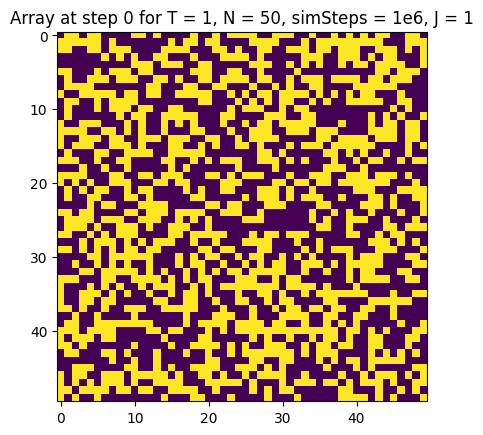

In [ ]:
plt.title('Array at step 0 for T = ' + str(T) + ', N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTSmall[0])

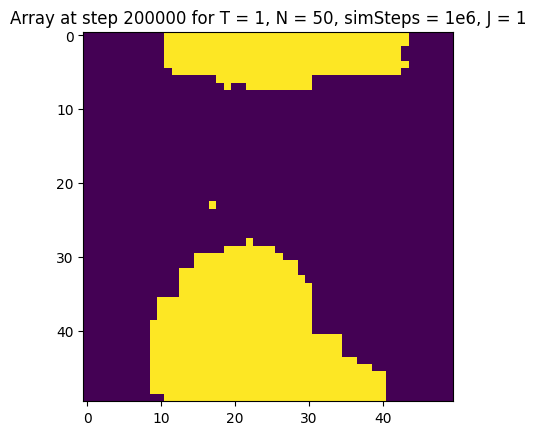

In [ ]:
plt.title('Array at step 200000 for T = ' + str(T) + ', N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTSmall[20000])

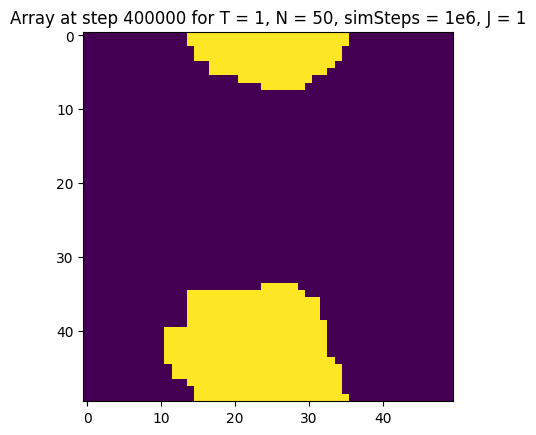

In [ ]:
plt.title('Array at step 400000 for T = ' + str(T) + ', N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTSmall[40000])

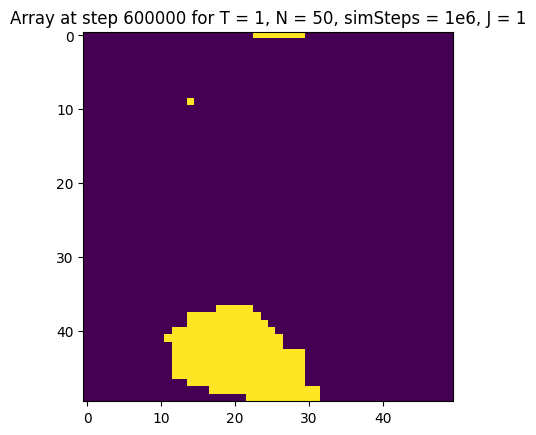

In [ ]:
plt.title('Array at step 600000 for T = ' + str(T) + ', N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTSmall[60000])

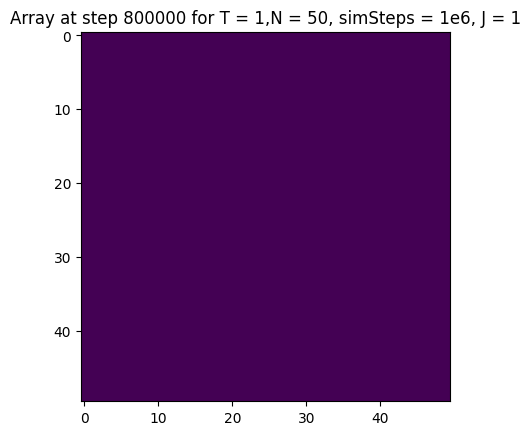

In [ ]:
plt.title('Array at step 800000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTSmall[80000])

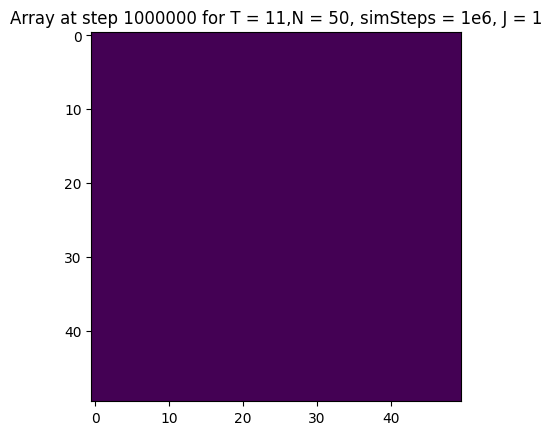

In [ ]:
plt.title('Array at step 1000000 for T = 1' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTSmall[100000])

In [ ]:
#for T = 2.27
T = 2.27
trajs, animationArraysTTwoPointTwoSeven = IsingModelArraysExtension(N, simSteps, J, T)

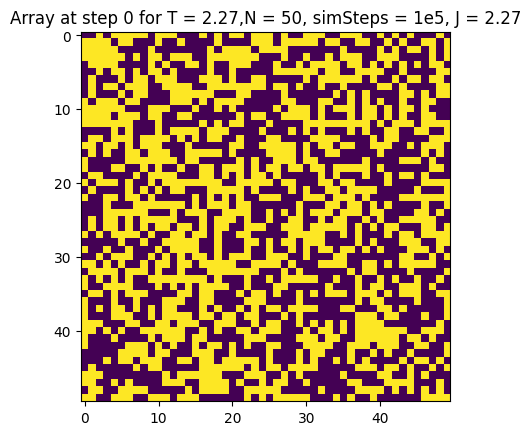

In [ ]:
plt.title('Array at step 0 for T = ' + str(T) + ',N = 50, simSteps = 1e5, J = 2.27')
plt.imshow(animationArraysTOne[0])

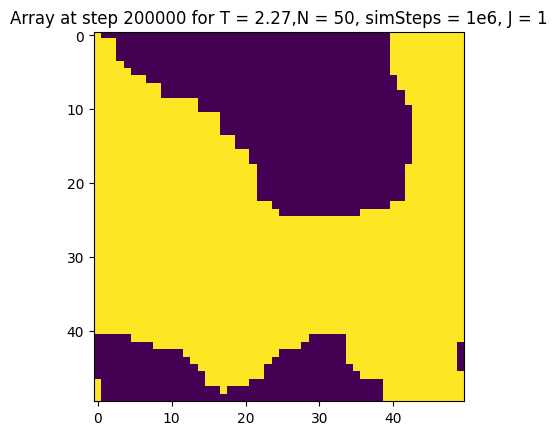

In [ ]:
plt.title('Array at step 200000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTOne[20000])

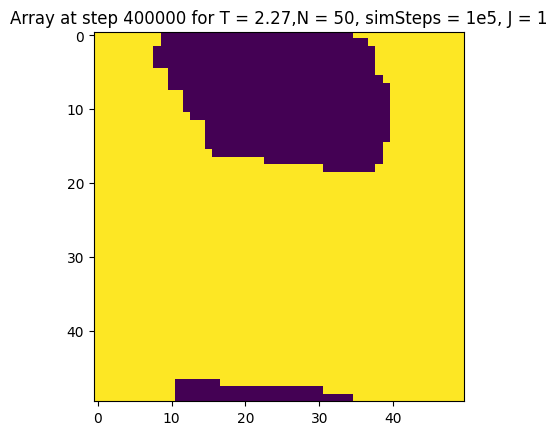

In [ ]:
plt.title('Array at step 400000 for T = ' + str(T) + ',N = 50, simSteps = 1e5, J = 1')
plt.imshow(animationArraysTOne[40000])

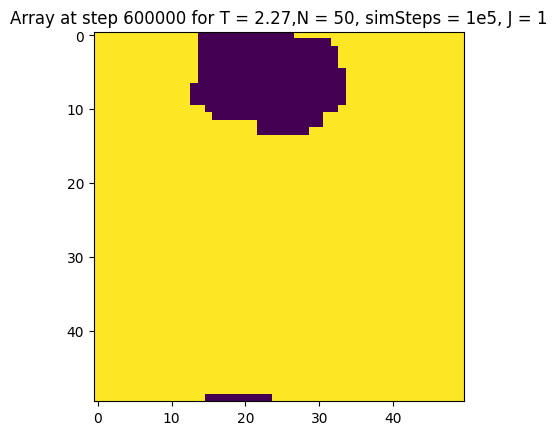

In [ ]:
plt.title('Array at step 600000 for T = ' + str(T) + ',N = 50, simSteps = 1e5, J = 1')
plt.imshow(animationArraysTOne[60000])

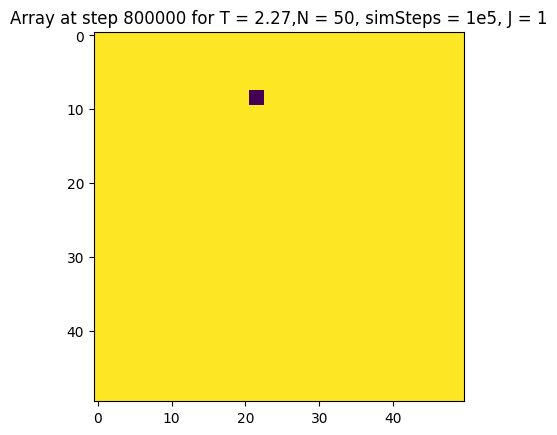

In [ ]:
plt.title('Array at step 800000 for T = ' + str(T) + ',N = 50, simSteps = 1e5, J = 1')
plt.imshow(animationArraysTOne[80000])

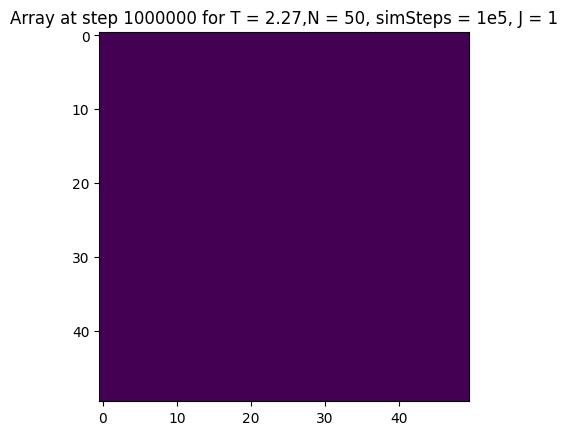

In [ ]:
plt.title('Array at step 1000000 for T = ' + str(T) + ',N = 50, simSteps = 1e5, J = 1')
plt.imshow(animationArraysTOne[100000])

In [ ]:
#for T = 5
T = 5
trajs, animationArraysTLarge = IsingModelArraysExtension(N, simSteps, J, T)

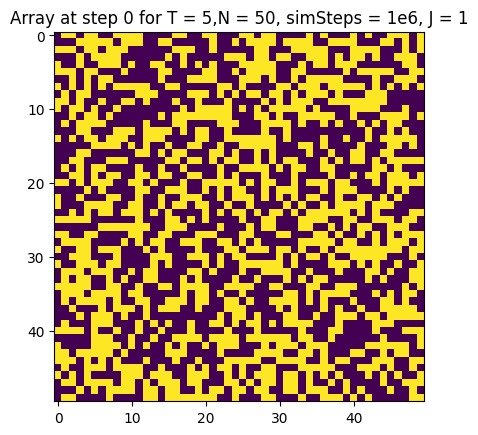

In [ ]:
plt.title('Array at step 0 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTLarge[0])

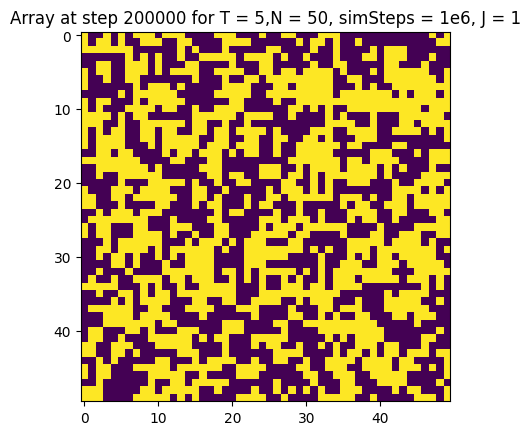

In [ ]:
plt.title('Array at step 200000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTLarge[20000])

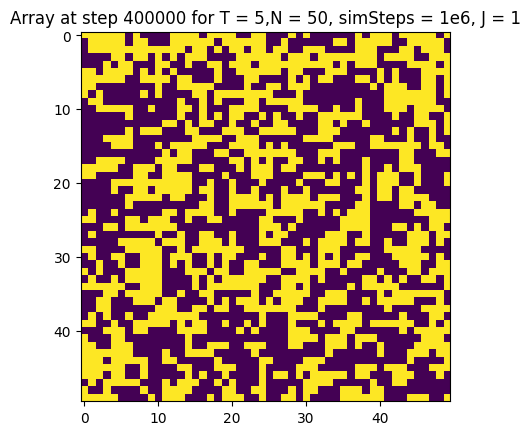

In [ ]:
plt.title('Array at step 400000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTLarge[40000])

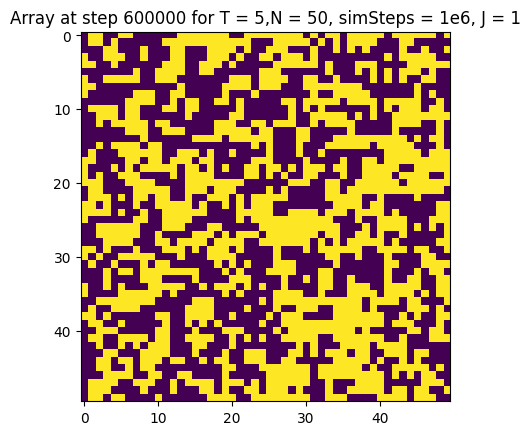

In [ ]:
plt.title('Array at step 600000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTLarge[60000])

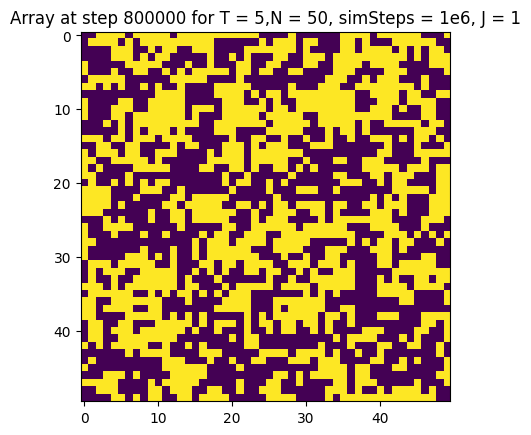

In [ ]:
plt.title('Array at step 800000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTLarge[80000])

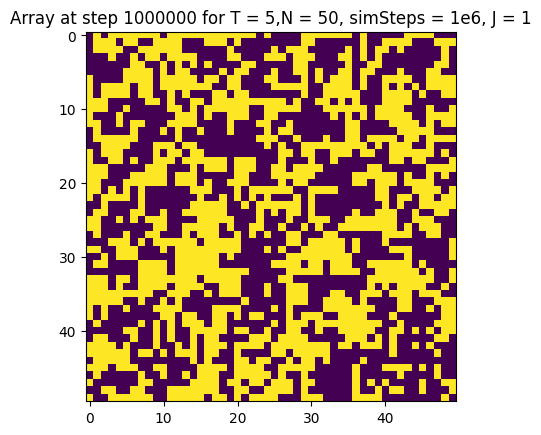

In [ ]:
plt.title('Array at step 1000000 for T = ' + str(T) + ',N = 50, simSteps = 1e6, J = 1')
plt.imshow(animationArraysTLarge[100000])

In [ ]:
#final experiments start here!

In [ ]:
#Simulation with J = 1, N = 50, simSteps = 1e5, T = 0.000001 (Get the image of the array with plt.imshow)
N = 50
simSteps = int(1e5)
J = 1
T = 0.000001
lowTempTrajectory, lowTempArrays = IsingModelArrays(N,simSteps,J,T)

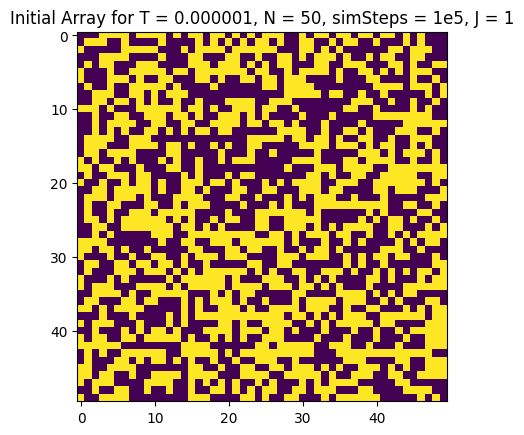

In [ ]:
plt.title('Initial Array for T = 0.000001, N = 50, simSteps = 1e5, J = 1')
plt.imshow(lowTempArrays[0])

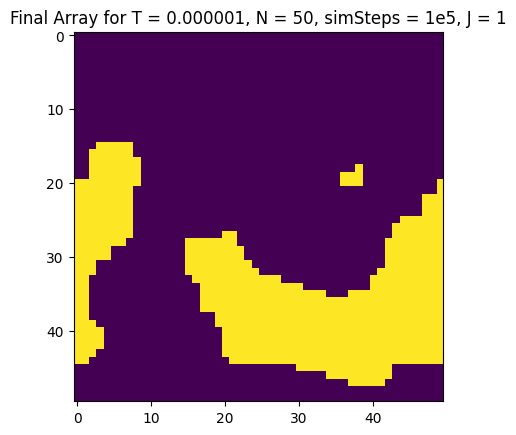

In [ ]:
plt.title('Final Array for T = 0.000001, N = 50, simSteps = 1e5, J = 1')
plt.imshow(lowTempArrays[int(1e5)//10])

In [ ]:
#Simulation with J = 1, N = 50, simSteps = 1e5, T = 100000 (Get the image of the array)
N = 50
simSteps = int(1e5)
J = 1
T = 100000
highTempTrajectory, highTempArrays = IsingModelArrays(N,simSteps,J,T,)

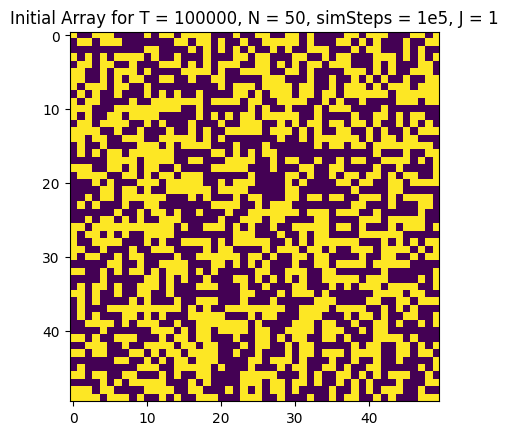

In [ ]:
plt.title('Initial Array for T = 100000, N = 50, simSteps = 1e5, J = 1')
plt.imshow(highTempArrays[0])

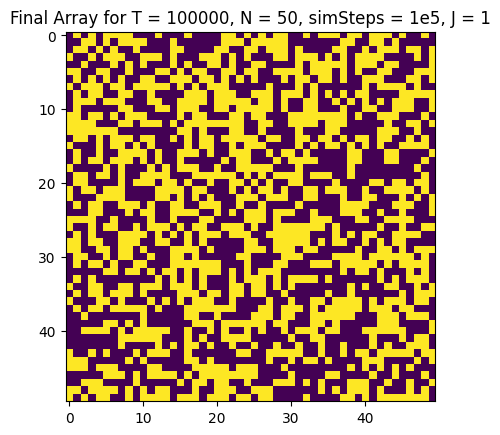

In [ ]:
plt.title('Final Array for T = 100000, N = 50, simSteps = 1e5, J = 1')
plt.imshow(highTempArrays[int(1e5)//10])

In [ ]:
#Run simulation with J = 1, N = 50, simSteps = 1e5, T = testTemps (make sure not discontinuity temps). Make a plot of average energy vs temperature, showing an inflection point at critical temp.

In [ ]:
N = 50
simSteps = int(1e5)
J = 1
testTemps = [0.01,0.1,0.5,1,2,2.269,3,4,5,6,7,8,9,10,12,14,15,16,18,20] #including critical temperature
print(len(testTemps)) # checking length of testTemps, want to have 20 items

20


In [ ]:
testTempsEs, testTempsIsingData = AverageEnergies(testTemps) #2h 45m runtime

'Initial Array for T = 100000, N = 50, simSteps = 1e5, J = 1'

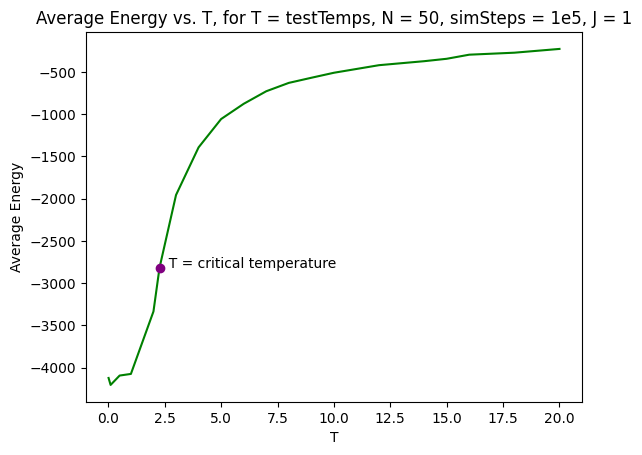

In [ ]:
plt.plot((testTemps),testTempsEs,color='Green')
plt.plot(2.269,testTempsEs[5],'o',color='Purple')
plt.annotate('  T = critical temperature',((2.269),testTempsEs[5]))
plt.xlabel('T')
plt.ylabel('Average Energy')
plt.title('Average Energy vs. T, for T = testTemps, N = ' + str(N)+ ', simSteps = 1e5, J = 1')

In [ ]:
#heat capacity C vs. T Simulation N = 50, simsteps = 1e5 , J = 1, T = testtemps

In [ ]:
testTemps = [0.01,0.1,0.5,1,2,2.269,3,4,5,6,7,8,9,10,12,14,15,16,18,20]

In [ ]:
testTempCs = []
for i in range(len(testTempsIsingData)):
  testTemptraj = testTempsIsingData[i][0]
  newC = C(testTemptraj,testTemps[i])
  testTempCs.append(newC)

Text(0.5, 1.0, 'Heat Capacity vs. T, for T = testTemps, N = 50, simSteps = 1e5, J = 1')

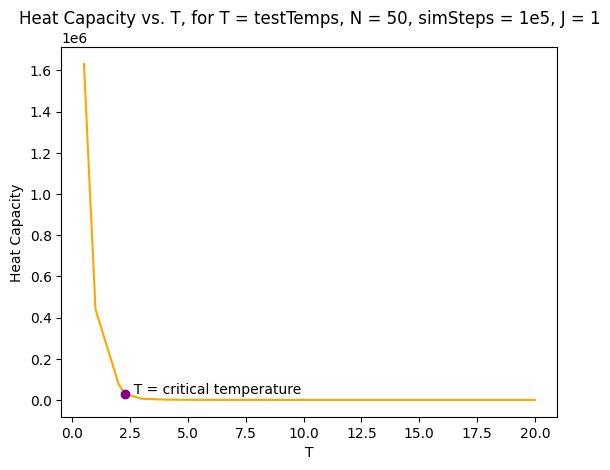

In [ ]:
testTemps.pop(0) #ran the pops two times
testTempCs.pop(0)
plt.plot((testTemps),testTempCs, color='Orange')
plt.annotate('  T = critical temperature',((2.269),testTempCs[3]))
plt.plot(2.269,testTempCs[3],'o' ,color='Purple')
plt.xlabel('T')
plt.ylabel('Heat Capacity')
plt.title('Heat Capacity vs. T, for T = testTemps, N = ' + str(N)+ ', simSteps = 1e5, J = 1')

In [ ]:
#Run simulation with J = 1, N = 50, simSteps = 1e5, T = testDiscontinuity. Make a plot of average energy vs temperature, showing an inflection point at critical temp.

In [ ]:
N = 50
simSteps = int(1e5)
J = 1
testDiscontinuity = testDiscontinuity = [2.00, 2.05, 2.10, 2.15, 2.20, 2.25, 2.269, 2.30, 2.35, 2.40, 2.45, 2.50, 2.55, 2.60, 2.65, 2.70, 2.75, 2.80, 2.85, 3.00]


In [ ]:
testDiscontinuityEs, testDiscontinuityIsingData = AverageEnergies(testDiscontinuity) #actually 2h 50m runtime

Text(0.5, 1.0, 'Average Energy vs. T, for T = testDiscontinuity, N = 50, simSteps = 1e5, J = 1')

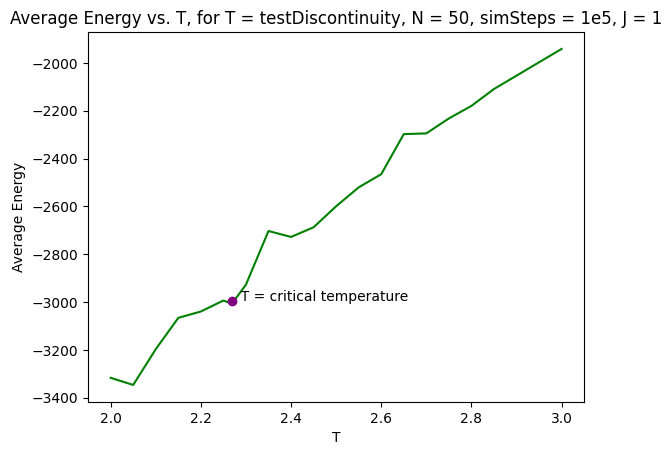

In [ ]:
plt.plot((testDiscontinuity),testDiscontinuityEs,color='Green')
plt.plot(2.269,testDiscontinuityEs[5],'o',color='Purple')
plt.annotate('  T = critical temperature',((2.269),testDiscontinuityEs[5]))
plt.xlabel('T')
plt.ylabel('Average Energy')
plt.title('Average Energy vs. T, for T = testDiscontinuity, N = ' + str(N)+ ', simSteps = 1e5, J = 1')

In [ ]:
#heat capacity C vs. T Simulation N = 50, simsteps = 1e5 , J = 1, T = testDiscontinuity

In [ ]:
N = 50
simSteps = int(1e5)
J = 1
testDiscontinuity = testDiscontinuity = [2.00, 2.05, 2.10, 2.15, 2.20, 2.25, 2.269, 2.30, 2.35, 2.40, 2.45, 2.50, 2.55, 2.60, 2.65, 2.70, 2.75, 2.80, 2.85, 3.00]


In [ ]:
testDiscontinuityEs, testDiscontinuityIsingData = AverageEnergies(testDiscontinuity)

In [ ]:
testDisCs = []
for i in range(len(testDiscontinuityIsingData)):
  testDiscontinuitytraj = testDiscontinuityIsingData[i][0]
  newC = C(testDiscontinuitytraj,testDiscontinuity[i])
  testDisCs.append(newC)

Text(0.5, 1.0, 'Heat Capacity vs. T, for T = testDiscontinuity, N = 50, simSteps = 1e5, J = 1')

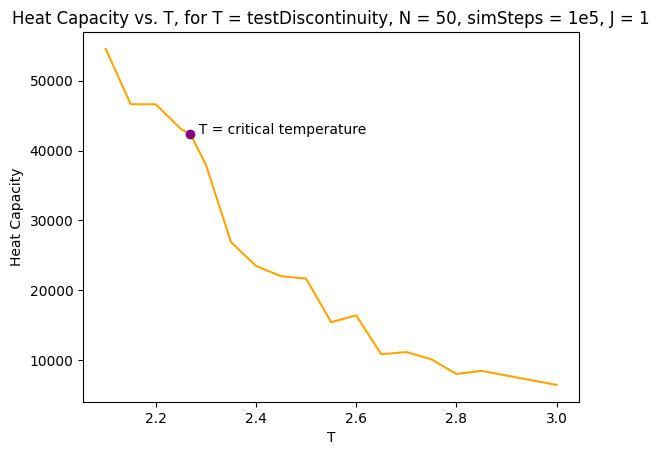

In [ ]:
testDiscontinuity.pop(0) #ran the pops two times
testDisCs.pop(0)
plt.plot((testDiscontinuity),testDisCs, color='Orange')
plt.annotate('  T = critical temperature',((2.269),testDisCs[4]))
plt.plot(2.269,testDisCs[4],'o' ,color='Purple')
plt.xlabel('T')
plt.ylabel('Heat Capacity')
plt.title('Heat Capacity vs. T, for T = testDiscontinuity, N = ' + str(N)+ ', simSteps = 1e5, J = 1')

In [ ]:
#testing a variety of Js for average energies vs. testTemps

In [ ]:
NTest = 50
simStepsTest = int(1e5)
testJs = [0, 1, 2, 5, 7,10] #these Js are not to iterate over directly but for reference
testJsTemps = [0.000001, 2.269, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100]

Text(0.5, 1.0, 'Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = 0, with extension code')

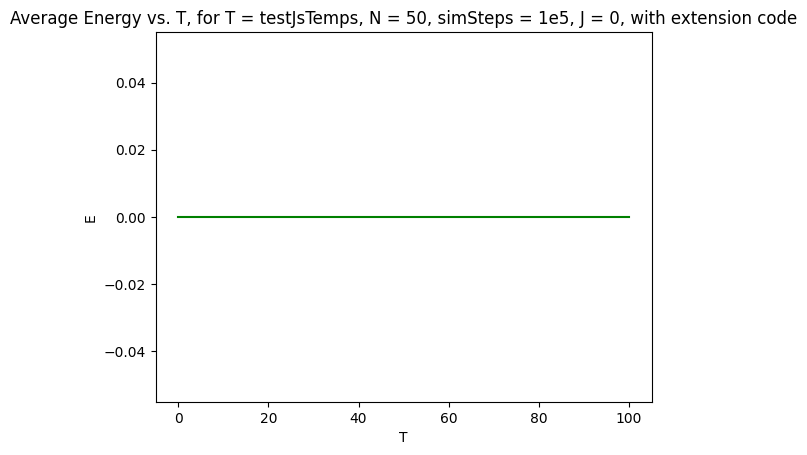

In [ ]:
#testing J = 0, using extension code to increase efficiency
JTest = 0
testJTwoEs, testJTwoIsingData = AverageEnergiesExtension(testJsTemps)

plt.plot((testJsTemps),testJTwoEs,color='Green')
plt.xlabel('T')
plt.ylabel('E')
plt.title('Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = ' + str(JTest) + ', with extension code')

Text(0.5, 1.0, 'Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = 1, with extension code')

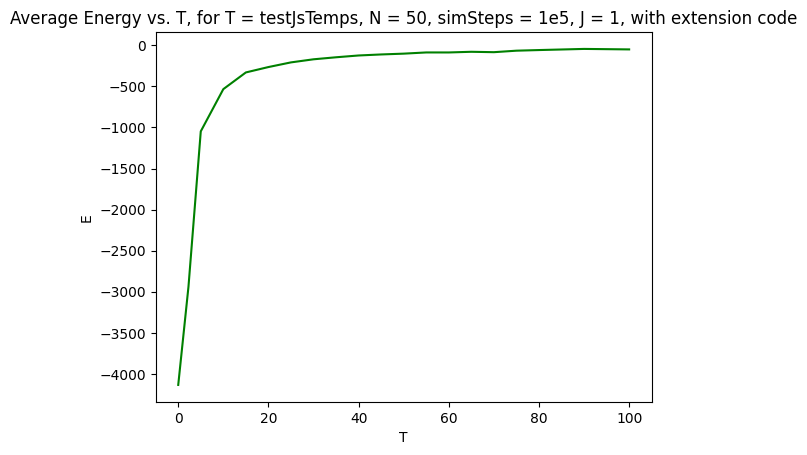

In [ ]:
#testing J = 1, using extension code to increase efficiency
JTest = 1
testJTwoEs, testJTwoIsingData = AverageEnergiesExtension(testJsTemps)

plt.plot((testJsTemps),testJTwoEs,color='Green')
plt.xlabel('T')
plt.ylabel('E')
plt.title('Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = ' + str(JTest) + ', with extension code')

Text(0.5, 1.0, 'Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = 2, with extension code')

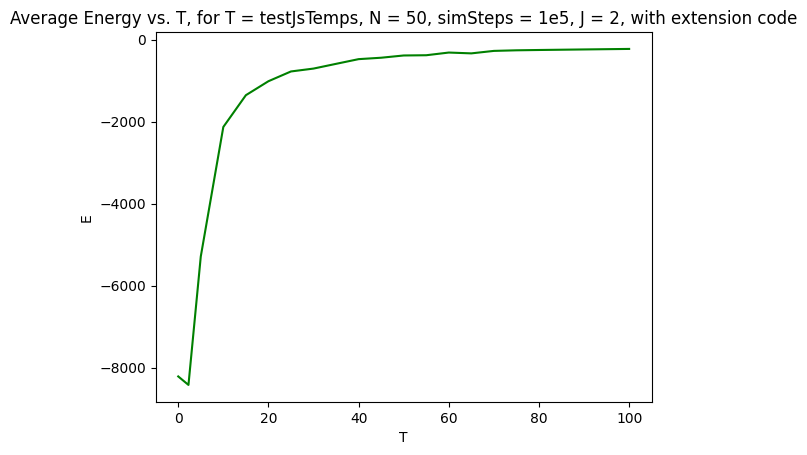

In [ ]:
#testing J = 2, using extension code to increase efficiency
JTest = 2
testJTwoEs, testJTwoIsingData = AverageEnergiesExtension(testJsTemps)

plt.plot((testJsTemps),testJTwoEs,color='Green')
plt.xlabel('T')
plt.ylabel('E')
plt.title('Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = ' + str(JTest) + ', with extension code')

Text(0.5, 1.0, 'Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = 5, with extension code')

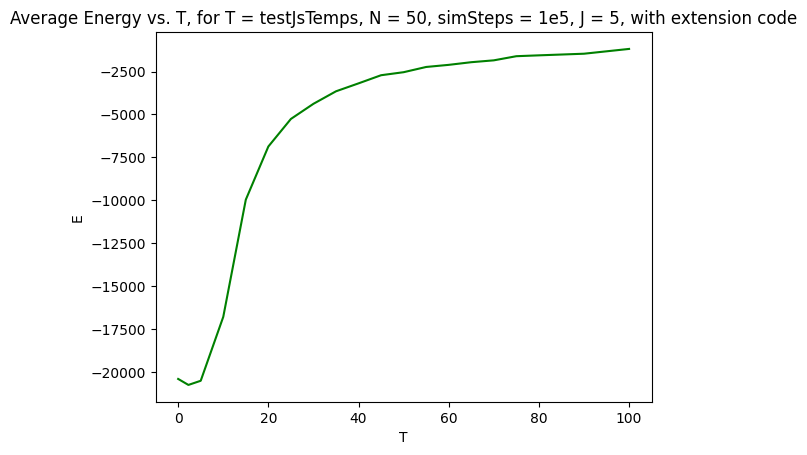

In [ ]:
#testing J = 5, using extension code to increase efficiency
JTest = 5
testJTwoEs, testJTwoIsingData = AverageEnergiesExtension(testJsTemps)

plt.plot((testJsTemps),testJTwoEs,color='Green')
plt.xlabel('T')
plt.ylabel('E')
plt.title('Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = ' + str(JTest) + ', with extension code')

Text(0.5, 1.0, 'Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = 7, with extension code')

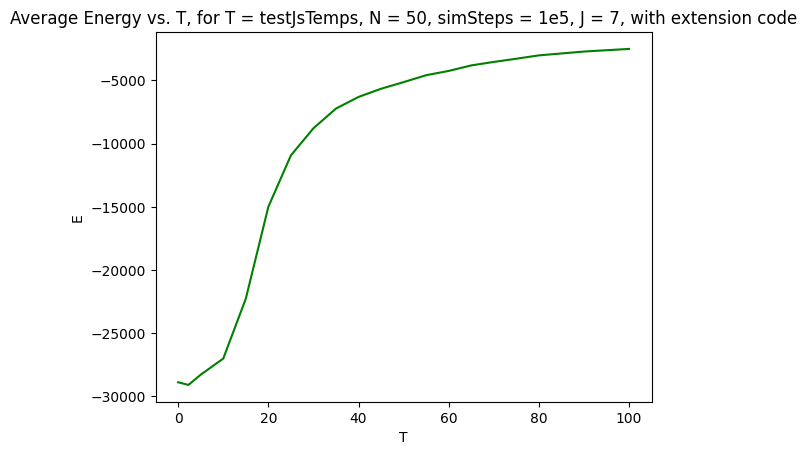

In [ ]:
#testing J = 7, using extension code to increase efficiency
JTest = 7
testJTwoEs, testJTwoIsingData = AverageEnergiesExtension(testJsTemps)

plt.plot((testJsTemps),testJTwoEs,color='Green')
plt.xlabel('T')
plt.ylabel('E')
plt.title('Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = ' + str(JTest) + ', with extension code')

Text(0.5, 1.0, 'Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = 10, with extension code')

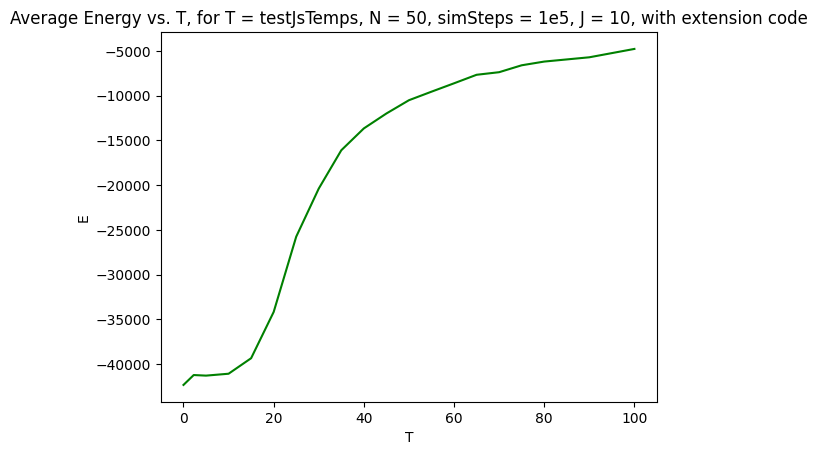

In [ ]:
#testing J = 10, using extension code to increase efficiency
JTest = 10
testJTwoEs, testJTwoIsingData = AverageEnergiesExtension(testJsTemps)

plt.plot((testJsTemps),testJTwoEs,color='Green')
plt.xlabel('T')
plt.ylabel('E')
plt.title('Average Energy vs. T, for T = testJsTemps, N = 50, simSteps = 1e5, J = ' + str(JTest) + ', with extension code')

In [ ]:
#testing of extension behavior starts here!

In [ ]:
#testing time of extension to complete one simulation
NTest = 50
simStepsTest = int(1e5)
JTest = 1
TTest = 1
oldT = time.time()
testExtensionTrajectory, testExtensionFrames = (IsingModelArraysExtension(NTest, simStepsTest, JTest, TTest)) #try when we are ready to commit to a couple of minutes
newT = time.time()
elapsedT = newT - oldT
print(elapsedT)

0.6473948955535889


0.6804125308990479


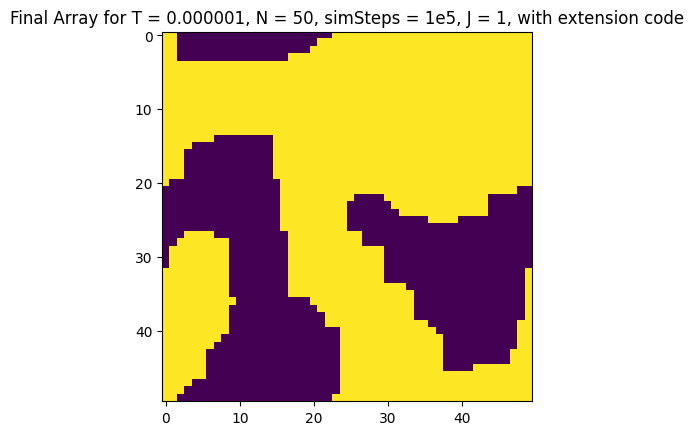

In [ ]:
#testing extension behavior, for cold
NTest = 50
simStepsTest = int(1e5)
JTest = 1
TTest = 0.000001
oldT = time.time()
testColdExtensionTrajectory, testColdExtensionFrames = (IsingModelArraysExtension(NTest, simStepsTest, JTest, TTest)) #try when we are ready to commit to a couple of minutes
newT = time.time()
elapsedT = newT - oldT
print(elapsedT)
plt.title('Final Array for T = 0.000001, N = 50, simSteps = 1e5, J = 1, with extension code')
plt.imshow(testColdExtensionFrames[int(1e5)//10])

0.761389970779419


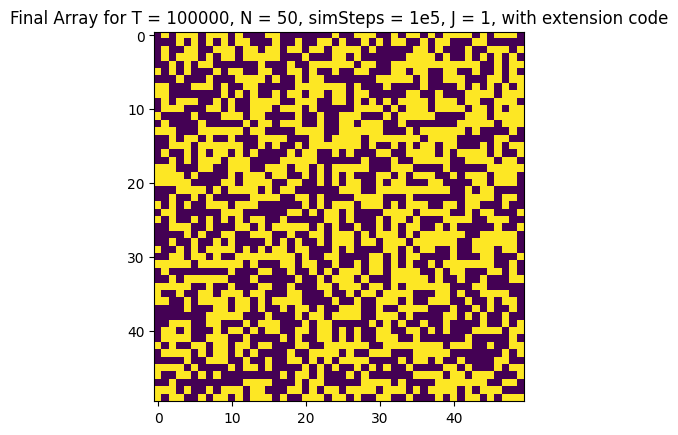

In [ ]:
#testing extension behavior, for hot
NTest = 50
simStepsTest = int(1e5)
JTest = 1
TTest = 100000
oldT = time.time()
testHotExtensionTrajectory, testHotExtensionFrames = (IsingModelArraysExtension(NTest, simStepsTest, JTest, TTest)) #try when we are ready to commit to a couple of minutes
newT = time.time()
elapsedT = newT - oldT
print(elapsedT)
plt.title('Final Array for T = 100000, N = 50, simSteps = 1e5, J = 1, with extension code')
plt.imshow(testHotExtensionFrames[int(1e5)//10])

6.705256938934326


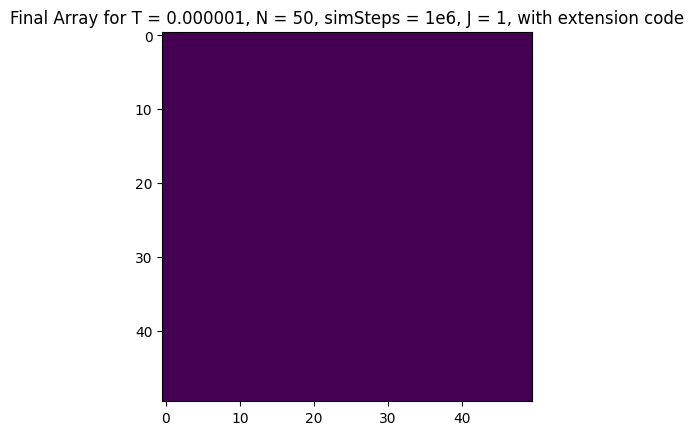

In [ ]:
#testing extension behavior, for cold, trying to see if we can get it to be fully uniform
NTest = 50
simStepsTest = int(1e6)
JTest = 1
TTest = 0.000001
oldT = time.time()
testColdExtensionTrajectory, testColdExtensionFrames = (IsingModelArraysExtension(NTest, simStepsTest, JTest, TTest)) #try when we are ready to commit to a couple of minutes
newT = time.time()
elapsedT = newT - oldT
print(elapsedT)
plt.title('Final Array for T = 0.000001, N = 50, simSteps = 1e6, J = 1, with extension code')
plt.imshow(testColdExtensionFrames[int(1e6)//10])

In [ ]:
testTemps = [0.01,0.1,0.5,1,2,2.269,3,4,5,6,7,8,9,10,12,14,15,16,18,20]

In [ ]:
oldT = time.time()
testTempsExtEs, testTempsExtIsingData = AverageEnergiesExtension(testTemps)
newT = time.time()
print(newT - oldT)

17.384113073349


Text(0.5, 1.0, 'Average Energy vs. T, for T = testTemps, N = 50, simSteps = 1e5, J = 1, with extension code')

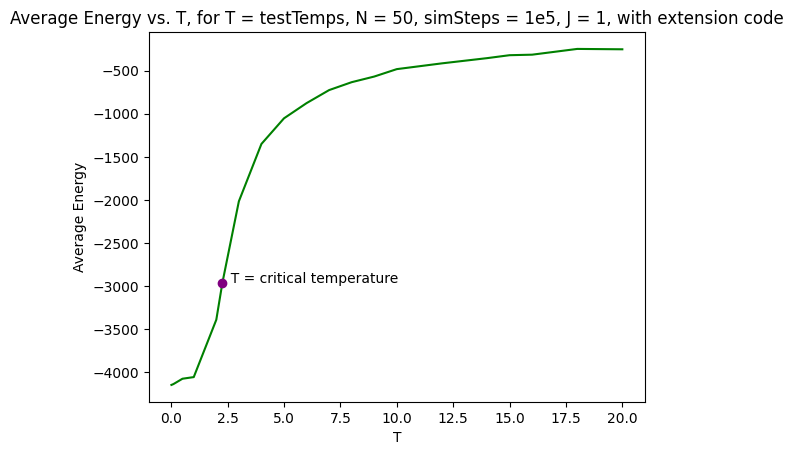

In [ ]:
plt.plot((testTemps),testTempsExtEs,color='Green')
plt.plot(2.269,testTempsExtEs[5],'o',color='Purple')
plt.annotate('  T = critical temperature',((2.269),testTempsExtEs[5]))
plt.xlabel('T')
plt.ylabel('Average Energy')
plt.title('Average Energy vs. T, for T = testTemps, N = ' + str(N)+ ', simSteps = 1e5, J = 1, with extension code')

In [ ]:
#testing time of non extension code to complete one simulation
NTest = 50
simStepsTest = int(1e5)
JTest = 1
TTest = 1
oldT = time.time()
testTrajectory, testFrames = (IsingModelArrays(NTest, simStepsTest, JTest, TTest)) #try when we are ready to commit to a couple of minutes
newT = time.time()
elapsedT = newT - oldT
print(elapsedT)